실습| MNIST 손글씨 인식하기: 컨볼루션 신경망 적용


Epoch 1: val_loss improved from inf to 0.07694, saving model to ./MNIST_CNN.hdf5

Epoch 2: val_loss improved from 0.07694 to 0.06004, saving model to ./MNIST_CNN.hdf5

Epoch 3: val_loss improved from 0.06004 to 0.05000, saving model to ./MNIST_CNN.hdf5

Epoch 4: val_loss did not improve from 0.05000

Epoch 5: val_loss improved from 0.05000 to 0.04970, saving model to ./MNIST_CNN.hdf5

Epoch 6: val_loss improved from 0.04970 to 0.04734, saving model to ./MNIST_CNN.hdf5

Epoch 7: val_loss improved from 0.04734 to 0.04311, saving model to ./MNIST_CNN.hdf5

Epoch 8: val_loss improved from 0.04311 to 0.04110, saving model to ./MNIST_CNN.hdf5

Epoch 9: val_loss did not improve from 0.04110

Epoch 10: val_loss did not improve from 0.04110

Epoch 11: val_loss improved from 0.04110 to 0.04077, saving model to ./MNIST_CNN.hdf5

Epoch 12: val_loss did not improve from 0.04077

Epoch 13: val_loss did not improve from 0.04077

Epoch 14: val_loss did not improve from 0.04077

Epoch 15: val_loss imp

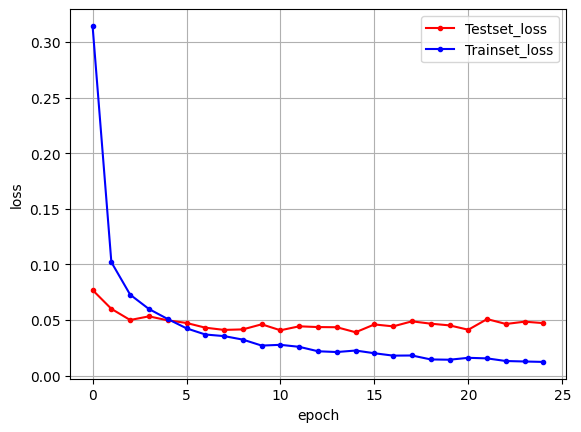

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np

# 데이터를 불러온다.
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# 컨볼루션 신경망의 설정
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), input_shape=(28, 28, 1),
                 activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# 모델의 실행 옵션을 설정한다.
model.compile(loss='categorical_crossentropy', optimizer='adam',
              metrics=['accuracy'])

# 모델 최적화를 위한 설정 구간이다.
modelpath = "./MNIST_CNN.hdf5"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델을 실행한다.
history = model.fit(X_train, y_train, validation_split=0.25, epochs=30,
                    batch_size=200, verbose=0, callbacks=[early_stopping_callback,
                                                          checkpointer])

# 테스트 정확도를 출력한다.
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))

# 검증셋과 학습셋의 오차를 저장한다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해본다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시한다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()